In [110]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

In [3]:
!wget $data

--2025-11-10 07:19:30--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  1019KB/s    in 0.8s    

2025-11-10 07:19:32 (1019 KB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [4]:
!head car_fuel_efficiency.csv

engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
170,3,159,3413.433758606219,17.7,2003,Europe,Gasoline,All-wheel drive,0,13.231728906241411
130,5,97,3149.6649342200353,17.8,2007,USA,Gasoline,Front-wheel drive,0,13.688217435463793
170,,78,3079.03899736884,15.1,2018,Europe,Gasoline,Front-wheel drive,0,14.246340998160866
220,4,,2542.392401828378,20.2,2009,USA,Diesel,All-wheel drive,2,16.91273559598635
210,1,140,3460.870989989018,14.4,2009,Europe,Gasoline,All-wheel drive,2,12.488369121964562
190,3,,2484.883986036068,14.7,2008,Europe,Gasoline,All-wheel drive,-1,17.271818372724237
240,7,127,3006.5422872171457,22.2,2012,USA,Gasoline,Front-wheel drive,1,13.210412112385608
150,4,239,3638.6577802809,17.3,2020,USA,Diesel,All-wheel drive,1,12.848883861524026
250,1,174,2714.219309645285,10.3,2016,Asia,Diesel,Front-wheel drive,-1,16.823553726916543


In [43]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [44]:
strings = list(df.dtypes[df.dtypes == 'object'].index)

In [45]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_').str.replace('-', '_')

In [46]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,europe,gasoline,all_wheel_drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,usa,gasoline,front_wheel_drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,europe,gasoline,front_wheel_drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,usa,diesel,all_wheel_drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,europe,gasoline,all_wheel_drive,2.0,12.488369


In [47]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [48]:
df = df.fillna(0)

In [59]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [49]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [50]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [52]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [53]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [54]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

In [67]:
dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(train_dicts)

In [68]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [69]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [70]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [71]:
y_pred = dt.predict(X_val)
rmse(y_val, y_pred)

np.float64(1.6104639028827592)

In [72]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



In [96]:
def train_rf_reg(n_est, X_train, y_train, X_val, y_val, max_depth=None):
    rf = RandomForestRegressor(n_estimators=n_est, random_state=1, n_jobs=-1, max_depth=max_depth)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rmse_score = rmse(y_val, y_pred)
    return rmse_score

In [97]:
train_rf_reg(10, X_train, y_train, X_val, y_val)

np.float64(0.4586615458484907)

In [98]:
ests = np.arange(10, 201, 10)

In [99]:
scores = []
for est in ests:
    rmse_score = train_rf_reg(est, X_train, y_train, X_val, y_val)
    scores.append((int(est), float(rmse_score.round(3))))
scores

[(10, 0.459),
 (20, 0.454),
 (30, 0.451),
 (40, 0.448),
 (50, 0.446),
 (60, 0.445),
 (70, 0.445),
 (80, 0.445),
 (90, 0.445),
 (100, 0.445),
 (110, 0.444),
 (120, 0.444),
 (130, 0.444),
 (140, 0.444),
 (150, 0.443),
 (160, 0.443),
 (170, 0.443),
 (180, 0.443),
 (190, 0.443),
 (200, 0.443)]

In [94]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse_val'])

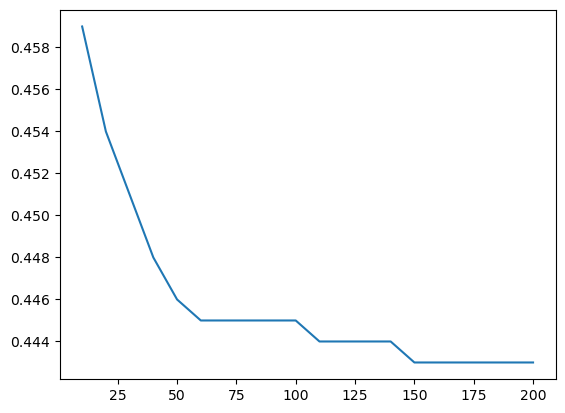

In [95]:
plt.plot(df_scores.n_estimators, df_scores['rmse_val'])

In [105]:
scores = []
max_depths = [10, 15, 20, 25]
for d in max_depths:
    rmse_vals = []
    for est in ests:
        rmse_score = train_rf_reg(est, X_train, y_train, X_val, y_val, max_depth=d)
        rmse_vals.append(float(rmse_score))
    scores.append((d, float(np.mean(rmse_vals))))
scores

[(10, 0.44187929925252156),
 (15, 0.44561628816456206),
 (20, 0.4456793443309614),
 (25, 0.4457024986347514)]

In [109]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, max_depth=20, n_jobs=-1)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
feature_names = dv.get_feature_names_out()
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

imp_df = imp_df.sort_values(
    by='importance', 
    ascending=False
)

imp_df

,feature,importance
13,vehicle_weight,0.959153
6,horsepower,0.016066
0,acceleration,0.011490
3,engine_displacement,0.003279
7,model_year,0.003170
8,num_cylinders,0.002333
9,num_doors,0.001618
12,origin=usa,0.000546
11,origin=europe,0.000513
10,origin=asia,0.000454


In [112]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [116]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100)
y_pred = model.predict(dval)
print(rmse(y_pred, y_val))

0.45017755678087246


In [117]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100)
y_pred = model.predict(dval)
print(rmse(y_pred, y_val))

0.42622800553359225
